# Tarea para el Hogar 05 — versión Python

Adaptación de `z494_python.ipynb` a la lógica de `z495_GustavoPasquini.ipynb`. La carga del dataset y la generación de la clase ternaria permanecen sin cambios.

# Librerías

In [1]:
import os
import cudf
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
import optuna
from optuna.samplers import GPSampler
from optuna.trial import TrialState
from optuna.visualization import plot_param_importances, plot_contour,  plot_slice, plot_optimization_history




print('cuDF:', cudf.__version__)
print('GPU:', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())


cuDF: 26.08.01
GPU: NVIDIA GeForce RTX 3090


In [2]:
import lightgbm as lgb
import yaml

# URLs

In [3]:
BASE_URL = os.path.join(
    os.path.expanduser("~"),
    "code", "DMEyF", "dmeyf2026"
)

DATA_URL = os.path.join(BASE_URL, "DATA")
DATASETS_URL = os.path.join(DATA_URL, "DATASETS")
EXP_URL = os.path.join(DATA_URL, "EXP")
dataset_url = os.path.join(DATASETS_URL, "competencia_01_crudo.csv")

experiment_name = "PY495-02"
EXPERIMENT_URL = os.path.join(EXP_URL, experiment_name)

os.makedirs(EXPERIMENT_URL, exist_ok=True)

# Constantes

In [4]:
SEED = 230047

In [5]:
PARAM = {
    "experimento": "HT4950-01",
    "semilla_primigenia": SEED,
    "training_pct": 70,
    "train": [202104],
    "train_final": [202104],
    "future": [202106],
    "cortes": list(range(9_000, 15_001, 500)),
    "trainingstrategy": {"undersampling": 0.1},
    "hyperparametertuning": {
        "iteraciones": 10,
        "n_startup_trials": 10,
    },
    "lgbm": {
        "param_fijos": {
            "boosting": "gbdt",
            "objective": "binary",
            "metric": "average_precision",
            "feature_pre_filter": False,
            "first_metric_only": False,
            "boost_from_average": True,
            "force_row_wise": True,
            "deterministic": True,
            "verbosity": -100,
            "seed": SEED,
            "max_depth": -1,
            "min_gain_to_split": 0.0,
            "lambda_l1": 0.0,
            "lambda_l2": 0.0,
            "max_bin": 31,
            "bagging_fraction": 1.0,
            "pos_bagging_fraction": 1.0,
            "neg_bagging_fraction": 1.0,
            "is_unbalance": False,
            "scale_pos_weight": 1.0,
            "drop_rate": 0.1,
            "max_drop": 50,
            "skip_drop": 0.5,
            "extra_trees": False,
            "early_stopping": 0,
            "min_data_in_leaf": 0,
            "feature_fraction": 0.50,
            # "learning_rate": 0.005,
  
        }
    },
    "out": {"lgbm": {}},
}


# Lectura del dataset

In [6]:
# cudf no pandas -> GPU
df = cudf.read_csv(
    dataset_url,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

In [7]:
df.head()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares,Visa_fultimo_cierre,Visa_mpagado,Visa_mpagospesos,Visa_mpagosdolares,Visa_fechaalta,Visa_mconsumototal,Visa_cconsumos,Visa_cadelantosefectivo,Visa_mpagominimo
0,12159854,202103,1,0,0,56,134,688.41,26701.84,98.82,...,0.0,1,0.0,-16247.77,0.0,4056,15732.34,1,0,1137.81
1,12159858,202103,1,0,0,48,102,78.43,24418.75,-73.62,...,NaN,<NA>,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,NaN
2,12160484,202103,1,0,0,60,55,8101.55,3162.23,13399.50,...,0.0,1,0.0,-31103.23,0.0,1632,2860.54,2,0,19858.89
3,12160591,202103,1,0,0,46,275,14825.78,138050.05,1146.27,...,0.0,1,0.0,-13733.44,0.0,2122,1419.36,3,0,1231.65
4,12160747,202103,1,0,0,47,194,2015.61,31240.49,1791.25,...,0.0,1,0.0,0.0,0.0,5901,1286.93,1,0,82.11


# Generación de la clase ternaria

In [8]:
# Índice de mes continuo para cada fila.
year = df['foto_mes'] // 100
month = df['foto_mes'] % 100
df['mes_idx'] = year * 12 + month

# Tabla de existencia: una fila por cliente y mes.
presencia = (
    df[['numero_de_cliente', 'mes_idx']]
    .drop_duplicates()
    .assign(presente=cp.int8(1))
)

# Presencia en t+1: desplazamos la clave para que coincida con el mes actual t.
presencia_t1 = presencia.rename(columns={'mes_idx': 'mes_idx_t1', 'presente': 'presente_t1'})
presencia_t1['mes_idx'] = presencia_t1['mes_idx_t1'] - 1
presencia_t1 = presencia_t1[['numero_de_cliente', 'mes_idx', 'presente_t1']]

# Presencia en t+2.
presencia_t2 = presencia.rename(columns={'mes_idx': 'mes_idx_t2', 'presente': 'presente_t2'})
presencia_t2['mes_idx'] = presencia_t2['mes_idx_t2'] - 2
presencia_t2 = presencia_t2[['numero_de_cliente', 'mes_idx', 'presente_t2']]

df = df.merge(presencia_t1, on=['numero_de_cliente', 'mes_idx'], how='left')
df = df.merge(presencia_t2, on=['numero_de_cliente', 'mes_idx'], how='left')

tiene_t1 = df['presente_t1'].fillna(0).astype('bool')
tiene_t2 = df['presente_t2'].fillna(0).astype('bool')

# Último mes observado del dataset: no tiene horizonte futuro verificable.
ultimo_mes_idx = int(df['mes_idx'].max())

df['ternaria'] = cudf.Series(None, index=df.index, dtype='str')
df.loc[df['mes_idx'] < ultimo_mes_idx - 1, 'ternaria'] = 'baja+1'
df.loc[(df['mes_idx'] < ultimo_mes_idx - 1) & tiene_t1, 'ternaria'] = 'baja+2'
df.loc[(df['mes_idx'] < ultimo_mes_idx - 1) & tiene_t1 & tiene_t2, 'ternaria'] = 'continua'

# Penúltimo mes: sólo puede determinarse baja+1; si continúa queda sin clase.
df.loc[(df['mes_idx'] == ultimo_mes_idx - 1) & ~tiene_t1, 'ternaria'] = 'baja+1'

# Quitamos columnas auxiliares.
df = df.drop(columns=['mes_idx', 'presente_t1', 'presente_t2'])
# Nulos en vez de NAN en CUDF
df.loc[df["ternaria"] == "", "ternaria"] = None

In [9]:
cudf.crosstab(df['ternaria'].fillna('NA'), df['foto_mes'])

foto_mes,202103,202104,202105,202106,202107,202108
ternaria,,,,,,
NA,0,0,0,0,163245,164647
baja+1,1019,964,1143,874,1103,0
baja+2,960,1139,870,1098,0,0
continua,160921,161181,161755,162142,0,0


In [10]:
df_completo = df.copy()

# Optimización de hiperparámetros

Se replica el presupuesto de z495: 10 evaluaciones totales. Como `mlr3mbo` usa por defecto un diseño inicial aleatorio de tamaño `4D` y aquí `D=3`, el presupuesto se agota durante la inicialización. En Optuna se reproduce con `n_startup_trials=10`, sin LHS explícito.

## Preprocesamiento

In [11]:
dataset_train_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train"])]
    .to_pandas()
    .reset_index(drop=True)
)

# Partición estratificada 70/30, equivalente a fold 1 y fold 2 en z495.
indices_fold_1, indices_fold_2 = train_test_split(
    np.arange(len(dataset_train_cpu)),
    train_size=PARAM["training_pct"] / 100,
    stratify=dataset_train_cpu["ternaria"],
    random_state=PARAM["semilla_primigenia"],
)

dataset_train_cpu["fold"] = np.int8(2)
dataset_train_cpu.loc[indices_fold_1, "fold"] = np.int8(1)

# BAJA+1 y BAJA+2 forman la clase positiva, igual que en el R.
dataset_train_cpu["clase01"] = (
    dataset_train_cpu["ternaria"].isin(["baja+1", "baja+2"])
    .astype(np.int8)
)

rng = np.random.default_rng(PARAM["semilla_primigenia"])
dataset_train_cpu["azar"] = rng.random(len(dataset_train_cpu))
dataset_train_cpu["training"] = (
    dataset_train_cpu["fold"].eq(1)
    & (
        (dataset_train_cpu["azar"] <= PARAM["trainingstrategy"]["undersampling"])
        | dataset_train_cpu["ternaria"].isin(["baja+1", "baja+2"])
    )
).astype(np.int8)

columnas_excluidas = {
    "ternaria",
    "clase01",
    "fold",
    "azar",
    "training",
    "cprestamos_personales",
    "mprestamos_personales",
}

campos_buenos = [
    columna
    for columna in dataset_train_cpu.columns
    if columna not in columnas_excluidas
]

mask_training = dataset_train_cpu["training"].eq(1)
X_train_bo = dataset_train_cpu.loc[mask_training, campos_buenos]
y_train_bo = dataset_train_cpu.loc[mask_training, "clase01"]

# Replica literalmente z495: validation contiene todas las filas con training == 0.
mask_validation = dataset_train_cpu["training"].eq(0)
X_validate_bo = dataset_train_cpu.loc[mask_validation, campos_buenos]
y_validate_bo = dataset_train_cpu.loc[mask_validation, "clase01"]

dtrain = lgb.Dataset(
    data=X_train_bo,
    label=y_train_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

dvalidate = lgb.Dataset(
    data=X_validate_bo,
    label=y_validate_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

print("Filas para training:", len(X_train_bo))
print("Filas para validation:", len(X_validate_bo))
print("Columnas:", len(campos_buenos))
dataset_train_cpu.groupby(["fold", "ternaria", "training"]).size()

Filas para training: 12829
Filas para validation: 150455
Columnas: 152


fold  ternaria  training
1     baja+1    1              675
      baja+2    1              797
      continua  0           101469
                1            11357
2     baja+1    0              289
      baja+2    0              342
      continua  0            48355
dtype: int64

## Función objetivo: Average Precision sobre validation

In [12]:
def estimar_ap_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    num_boost_round = int(parametros_completos.pop("num_iterations"))

    modelo = lgb.train(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
        valid_sets=[dvalidate],
        valid_names=["val"],
    )

    return float(modelo.best_score["val"]["average_precision"])

In [13]:
def objective(trial):
    parametros_variables = {
        "num_iterations": trial.suggest_int("num_iterations", 64, 4096),
        "num_leaves": trial.suggest_int("num_leaves", 16, 2048),
        "min_sum_hessian_in_leaf": trial.suggest_float(
            "min_sum_hessian_in_leaf", 1e-6, 0.1
        ),
        "learning_rate": trial.suggest_float("learning_rate", 0.003, 0.006),
    }
    return estimar_ap_lightgbm(parametros_variables)

## Estudio Optuna y reanudación

In [14]:
n_startup_trials = PARAM["hyperparametertuning"]["n_startup_trials"]
n_trials_total = PARAM["hyperparametertuning"]["iteraciones"]

sampler = GPSampler(
    seed=PARAM["semilla_primigenia"],
    n_startup_trials=n_startup_trials,
    deterministic_objective=False,
)

study_db_url = os.path.join(EXPERIMENT_URL, "optuna_study.db")
storage_url = f"sqlite:///{study_db_url}"

study = optuna.create_study(
    study_name=experiment_name,
    direction="maximize",
    sampler=sampler,
    storage=storage_url,
    load_if_exists=True,
)

/tmp/ipykernel_227376/1912430851.py:4: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler = GPSampler(
[I 2026-09-09 20:23:31,807] A new study created in RDB with name: PY495-02


In [15]:
trials_completos = sum(
    trial.state == TrialState.COMPLETE
    for trial in study.trials
)
trials_restantes = max(0, n_trials_total - trials_completos)

print("Trials completos:", trials_completos)
print("Trials restantes:", trials_restantes)

if trials_restantes > 0:
    study.optimize(
        objective,
        n_trials=trials_restantes,
        show_progress_bar=True,
    )
else:
    print("c'est fini")

Trials completos: 0
Trials restantes: 10


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-09-09 20:23:45,879] Trial 0 finished with value: 0.07927925119326025 and parameters: {'num_iterations': 437, 'num_leaves': 940, 'min_sum_hessian_in_leaf': 0.06822865908726443, 'learning_rate': 0.0031633383990986477}. Best is trial 0 with value: 0.07927925119326025.
[I 2026-09-09 20:25:12,738] Trial 1 finished with value: 0.08990178766125943 and parameters: {'num_iterations': 3178, 'num_leaves': 1282, 'min_sum_hessian_in_leaf': 0.004493681743571102, 'learning_rate': 0.005127704326290953}. Best is trial 1 with value: 0.08990178766125943.
[I 2026-09-09 20:26:29,280] Trial 2 finished with value: 0.09419057662333676 and parameters: {'num_iterations': 2587, 'num_leaves': 1903, 'min_sum_hessian_in_leaf': 0.04878865928600168, 'learning_rate': 0.004737026387082675}. Best is trial 2 with value: 0.09419057662333676.
[I 2026-09-09 20:27:05,329] Trial 3 finished with value: 0.09601504216716117 and parameters: {'num_iterations': 1920, 'num_leaves': 542, 'min_sum_hessian_in_leaf': 0.077846450

## Resultados de la optimización

In [16]:
tb_bayesiana = study.trials_dataframe()
tb_bayesiana["iter"] = np.arange(1, len(tb_bayesiana) + 1)
tb_bayesiana = (
    tb_bayesiana
    .sort_values("value", ascending=False, na_position="last")
    .reset_index(drop=True)
)
tb_bayesiana.to_csv(
    os.path.join(EXPERIMENT_URL, "BO_log.txt"),
    sep="	",
    index=False,
)

PARAM["out"]["lgbm"]["mejores_hiperparametros"] = dict(study.best_trial.params)
PARAM["out"]["lgbm"]["y"] = float(study.best_value)

with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)

print(PARAM["out"]["lgbm"]["mejores_hiperparametros"])
print("Mejor Average Precision:", PARAM["out"]["lgbm"]["y"])
tb_bayesiana.head()

{'num_iterations': 2780, 'num_leaves': 24, 'min_sum_hessian_in_leaf': 0.06401048181778245, 'learning_rate': 0.003697843940282776}
Mejor Average Precision: 0.11828306056804352


,number,value,datetime_start,datetime_complete,duration,params_learning_rate,params_min_sum_hessian_in_leaf,params_num_iterations,params_num_leaves,state,iter
0,4,0.118283,2026-09-09 20:27:05.341118,2026-09-09 20:27:20.911483,0 days 00:00:15.570365,0.003698,0.064010,2780,24,COMPLETE,5
1,9,0.111733,2026-09-09 20:30:29.760499,2026-09-09 20:30:52.112671,0 days 00:00:22.352172,0.004972,0.016186,2793,93,COMPLETE,10
2,5,0.097014,2026-09-09 20:27:20.955801,2026-09-09 20:28:22.119889,0 days 00:01:01.164088,0.003735,0.055019,4040,662,COMPLETE,6
3,3,0.096015,2026-09-09 20:26:29.288820,2026-09-09 20:27:05.302222,0 days 00:00:36.013402,0.004596,0.077846,1920,542,COMPLETE,4
4,8,0.094711,2026-09-09 20:29:09.101686,2026-09-09 20:30:29.723991,0 days 00:01:20.622305,0.003124,0.007455,3915,640,COMPLETE,9


In [17]:
plot_optimization_history(study)

In [18]:
plot_slice(study)

In [19]:
plot_contour(study)

# Producción

## Final training sobre todos los datos de 202104

In [20]:
dataset_final_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train_final"])]
    .to_pandas()
    .reset_index(drop=True)
)
dataset_final_cpu["clase01"] = (
    dataset_final_cpu["ternaria"].isin(["baja+1", "baja+2"])
    .astype(np.int8)
)

dataset_final_cpu.groupby("ternaria").size()

ternaria
baja+1         964
baja+2        1139
continua    161181
dtype: int64

In [21]:
param_final = {
    **PARAM["lgbm"]["param_fijos"],
    **PARAM["out"]["lgbm"]["mejores_hiperparametros"],
}

num_boost_round_final = int(param_final.pop("num_iterations"))
param_final

{'boosting': 'gbdt',
 'objective': 'binary',
 'metric': 'average_precision',
 'feature_pre_filter': False,
 'first_metric_only': False,
 'boost_from_average': True,
 'force_row_wise': True,
 'deterministic': True,
 'verbosity': -100,
 'seed': 230047,
 'max_depth': -1,
 'min_gain_to_split': 0.0,
 'lambda_l1': 0.0,
 'lambda_l2': 0.0,
 'max_bin': 31,
 'bagging_fraction': 1.0,
 'pos_bagging_fraction': 1.0,
 'neg_bagging_fraction': 1.0,
 'is_unbalance': False,
 'scale_pos_weight': 1.0,
 'drop_rate': 0.1,
 'max_drop': 50,
 'skip_drop': 0.5,
 'extra_trees': False,
 'early_stopping': 0,
 'min_data_in_leaf': 0,
 'feature_fraction': 0.5,
 'num_leaves': 24,
 'min_sum_hessian_in_leaf': 0.06401048181778245,
 'learning_rate': 0.003697843940282776}

In [22]:
dtrain_final = lgb.Dataset(
    data=dataset_final_cpu[campos_buenos],
    label=dataset_final_cpu["clase01"],
    feature_name=campos_buenos,
)

modelo_final = lgb.train(
    params=param_final,
    train_set=dtrain_final,
    num_boost_round=num_boost_round_final,
)

## Importancia de variables y modelo

In [23]:
arboles_df = modelo_final.trees_to_dataframe()
splits_df = arboles_df.loc[arboles_df["split_feature"].notna()]

tb_importancia = (
    splits_df
    .groupby("split_feature", as_index=False)
    .agg(
        Gain=("split_gain", "sum"),
        Cover=("count", "sum"),
        Frequency=("split_feature", "size"),
    )
    .rename(columns={"split_feature": "Feature"})
)

for columna in ["Gain", "Cover", "Frequency"]:
    total = tb_importancia[columna].sum()
    if total > 0:
        tb_importancia[columna] = tb_importancia[columna] / total

tb_importancia = tb_importancia.sort_values("Gain", ascending=False)
tb_importancia.to_csv(
    os.path.join(EXPERIMENT_URL, "impo.txt"),
    sep="\t",
    index=False,
)
modelo_final.save_model(os.path.join(EXPERIMENT_URL, "modelo.txt"))

tb_importancia.head(20)

,Feature,Gain,Cover,Frequency
98,ctrx_quarter,0.167041,0.044009,0.022599
104,mcaja_ahorro,0.072024,0.012318,0.016969
77,cpayroll_trx,0.044248,0.033224,0.012449
127,mpayroll,0.043129,0.047735,0.016109
126,mpasivos_margen,0.040650,0.017355,0.017814
117,mcuentas_saldo,0.038611,0.025377,0.025023
137,mtarjeta_visa_consumo,0.038317,0.008709,0.009790
81,cproductos,0.026208,0.044248,0.021880
134,mrentabilidad_annual,0.022124,0.039705,0.029371
115,mcuenta_corriente,0.021809,0.007316,0.019159


## Scoring sobre 202106

In [24]:
dfuture_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["future"])]
    .to_pandas()
    .reset_index(drop=True)
)

prediccion = modelo_final.predict(dfuture_cpu[campos_buenos])

tb_prediccion = dfuture_cpu[["numero_de_cliente", "foto_mes", "ternaria"]].copy()
tb_prediccion["prob"] = prediccion
tb_prediccion[["numero_de_cliente", "foto_mes", "prob"]].to_csv(
    os.path.join(EXPERIMENT_URL, "prediccion.txt"),
    sep="\t",
    index=False,
)

tb_prediccion.head()

,numero_de_cliente,foto_mes,ternaria,prob
0,13096674,202106,continua,0.000523
1,13096681,202106,continua,0.000475
2,13096806,202106,continua,0.007014
3,13096852,202106,continua,0.020508
4,13074119,202106,continua,0.000429


## Curva de ganancia

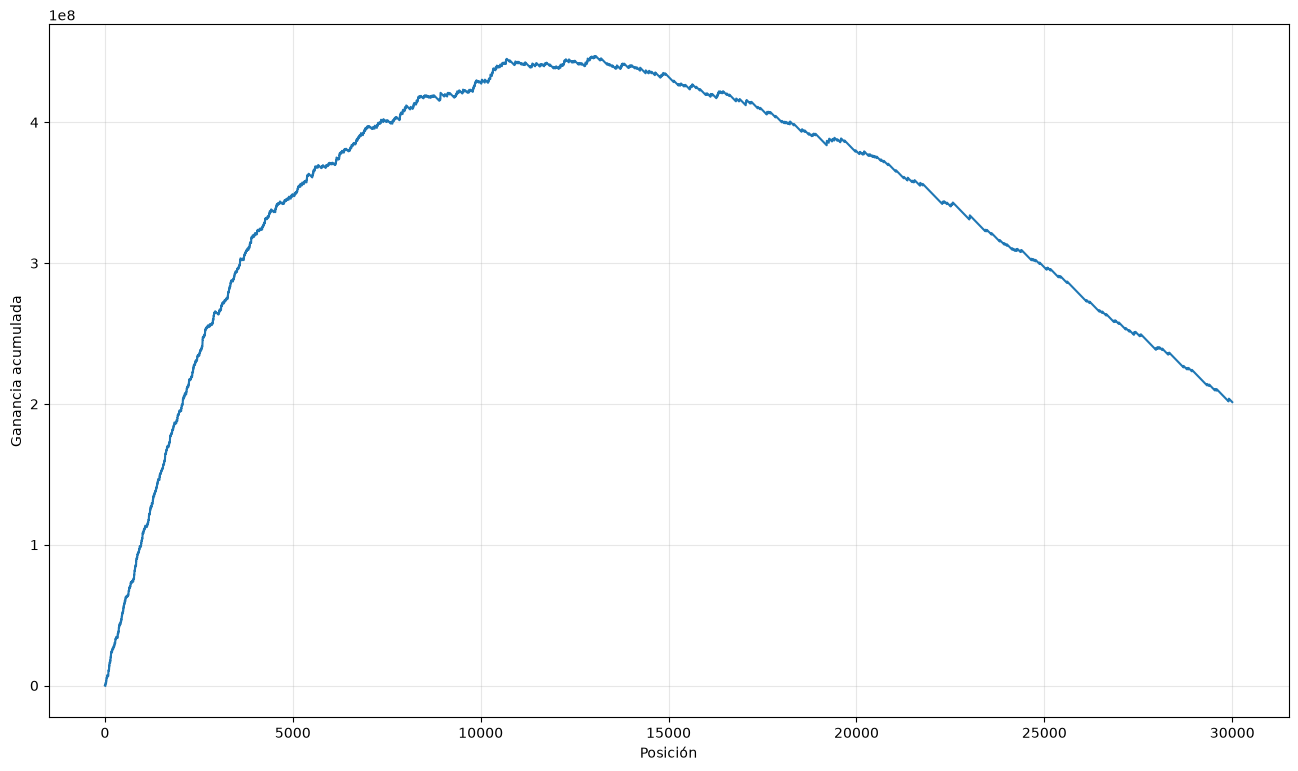

In [25]:
tb_prediccion = tb_prediccion.sort_values("prob", ascending=False).reset_index(drop=True)
tb_prediccion["gan"] = np.where(
    tb_prediccion["ternaria"].eq("baja+2"),
    1_072_500,
    -27_500,
)
tb_prediccion["ganancia_acumulada"] = tb_prediccion["gan"].cumsum()
tb_prediccion["pos"] = np.arange(1, len(tb_prediccion) + 1)

amostrar = 30_000
datos_plot = tb_prediccion.loc[tb_prediccion["pos"] <= amostrar]

plt.figure(figsize=(16, 9))
plt.plot(datos_plot["pos"], datos_plot["ganancia_acumulada"])
plt.xlabel("Posición")
plt.ylabel("Ganancia acumulada")
plt.grid(alpha=0.3)
plt.show()

## Ganancia bajo distintos cortes

In [26]:
resultados_cortes = []

for envios in PARAM["cortes"]:
    ganancia = tb_prediccion.iloc[:envios]["gan"].sum()
    resultados_cortes.append({
        "envios": envios,
        "ganancia": ganancia,
    })
    print(f"{envios}	{ganancia:.0f}")

resultados_cortes_df = pd.DataFrame(resultados_cortes)
resultados_cortes_df

9000	419100000
9500	420750000
10000	427900000
10500	439450000
11000	442200000
11500	441650000
12000	438900000
12500	442750000
13000	445500000
13500	439450000
14000	440000000
14500	436150000
15000	432300000


,envios,ganancia
0,9000,419100000
1,9500,420750000
2,10000,427900000
3,10500,439450000
4,11000,442200000
5,11500,441650000
6,12000,438900000
7,12500,442750000
8,13000,445500000
9,13500,439450000


In [27]:
with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)